<a href="https://colab.research.google.com/github/Tusharchauhan1302/Brain_Tumor_Detection/blob/main/Brain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Library

In [ ]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance

# Corrected module names below (.models and .layers)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

Load dataset

In [ ]:
# Directories for training and test data
train_dir = '/content/drive/MyDrive/Brain/Training'
test_dir =  '/content/drive/MyDrive/Brain/Testing'

#load and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths = []
test_labels = []
for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(train_dir, label, image))
    test_labels.append(label)

test_path, test_labels = shuffle(test_paths, test_labels)

Data visualization

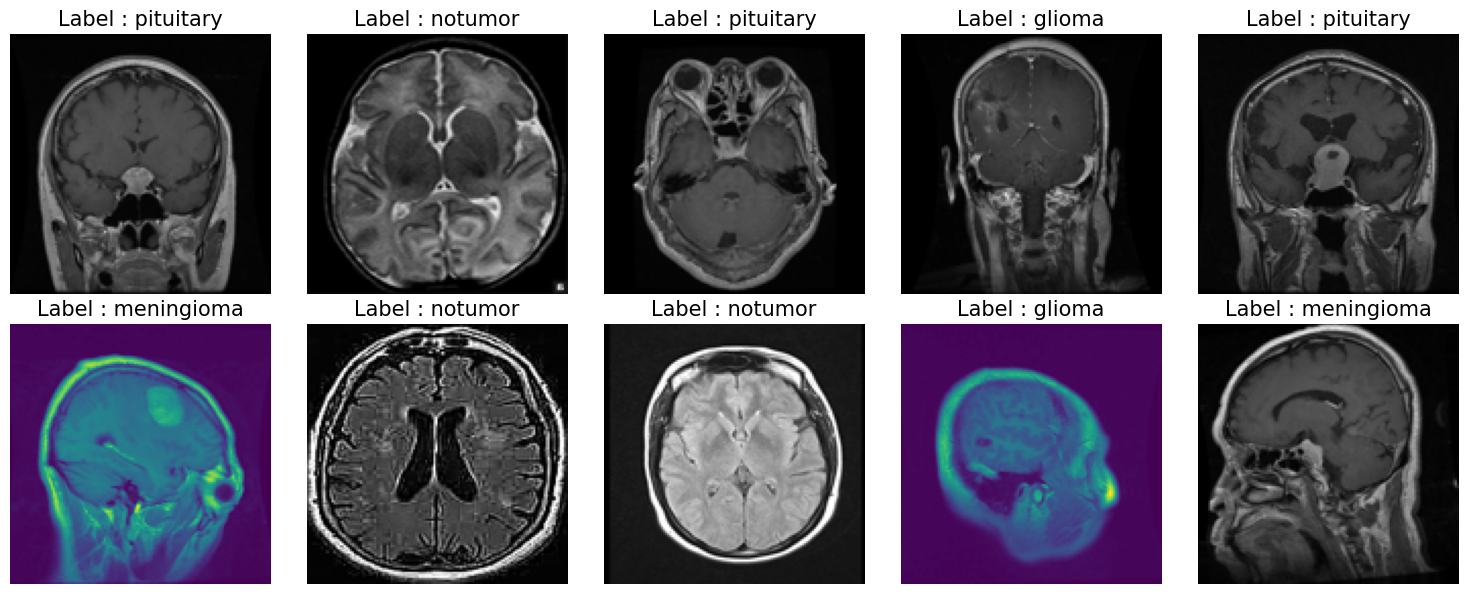

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os


#Select random indcies for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2,5, figsize=(15, 6))
axes = axes.ravel()

# Loop thorugh the random indcies and display images
for i, index in enumerate(random_indices):
  img_path = train_paths[index]
  img = Image.open(img_path)
  img = img.resize((128, 128))


  # Display images
  axes[i].imshow(img)
  axes[i].axis("off")
  axes[i].set_title(f"Label : {train_labels[index]}", fontsize = 15)


plt.tight_layout()
plt.show()


Image pre processing

In [ ]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  #  contrast
    image = np.array(image) / 255.0
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

In [ ]:
# Model architecture
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])


batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 2809s 10s/step - loss: 0.4579 - sparse_categorical_accuracy: 0.8250
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 871s 3s/step - loss: 0.2474 - sparse_categorical_accuracy: 0.9052
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 869s 3s/step - loss: 0.1721 - sparse_categorical_accuracy: 0.9339
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 879s 3s/step - loss: 0.1173 - sparse_categorical_accuracy: 0.9555
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 876s 3s/step - loss: 0.0947 - sparse_categorical_accuracy: 0.9666


Train and val plots

AttributeError: module 'matplotlib.pyplot' has no attribute 'tittle'

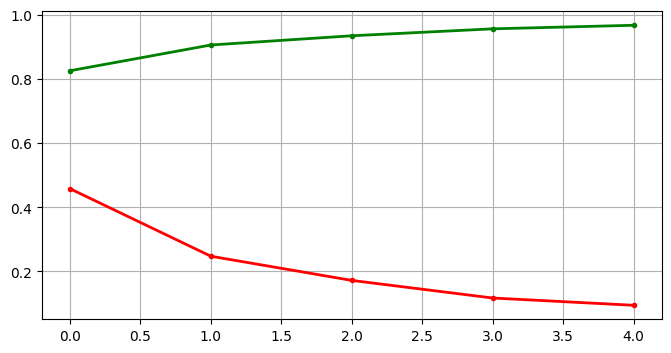

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth = 2)
plt.plot(history.history['loss'], '.r-', linewidth = 2)
plt.tittle('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc = 'upper left', bbox_to_anchor = (1,1))
plt.show()


Model classification report

In [3]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis =1)))

NameError: name 'open_images' is not defined

Model cofusion Plot

In [6]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix")
print(conf_matrix)

plt.figure(figsize = (8,6))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = os.listdir(train_dir), yticklabels = os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


NameError: name 'test_labels_encoded' is not defined